In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE


Overall P(y=1) = 0.0664  |  counts: y=1 -> 104, y=0 -> 1463

[Monthly fail ratio]
            fail_ratio    n
Time                       
2008-01-31      0.0588   51
2008-02-29      0.0510   98
2008-03-31      0.0200   50
2008-04-30      0.0612   49
2008-05-31      0.1129   62
2008-06-30      0.0896   67
2008-07-31      0.1404  114
2008-08-31      0.0807  471
2008-09-30      0.0412  413
2008-10-31      0.0488  123
2008-11-30      0.0571   35
2008-12-31      0.0000   34


C:\Users\USER\AppData\Local\Temp\ipykernel_14864\2747578377.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_tbl = pd.concat([df['y'].resample('M').mean().rename('fail_ratio'),
C:\Users\USER\AppData\Local\Temp\ipykernel_14864\2747578377.py:32: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['y'].resample('M').size().rename('n')], axis=1)


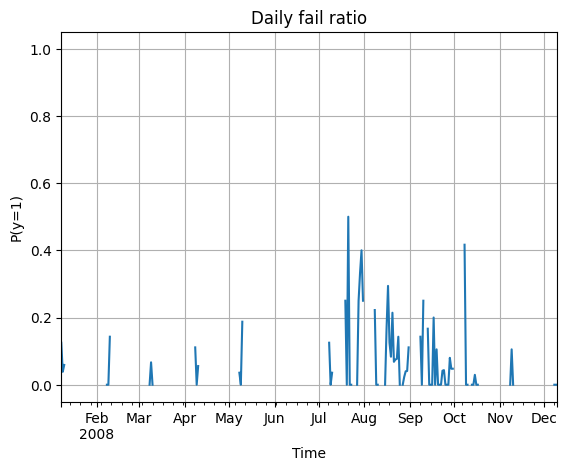

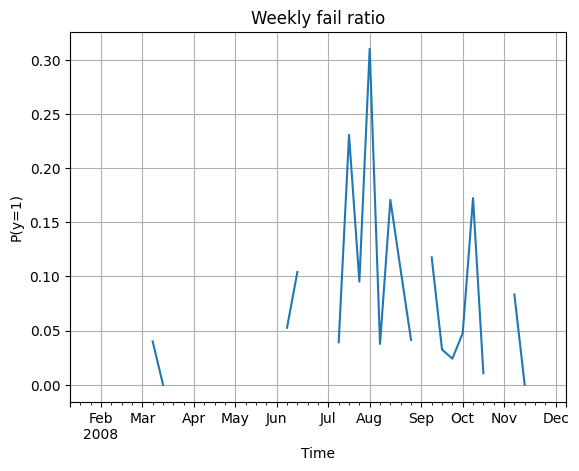

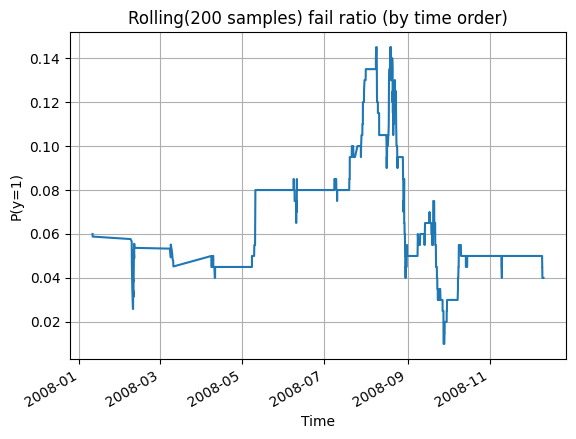

In [9]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# 讀檔
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)
time_raw = secom['Time']

print(f"Overall P(y=1) = {y.mean():.4f}  |  counts: y=1 -> {int((y==1).sum())}, y=0 -> {int((y==0).sum())}")

# 嘗試把 Time 轉為 datetime；若多為 NaT 就視為數值序列使用 row order
time_dt = pd.to_datetime(time_raw, errors='coerce')
use_datetime = time_dt.notna().mean() >= 0.7  # 至少 70% 可解析才視為時間戳

if use_datetime:
    df = pd.DataFrame({'Time': time_dt, 'y': y}).dropna(subset=['Time']).sort_values('Time').set_index('Time')

    # 每日/每週不良率
    daily = df['y'].resample('D').mean()
    weekly = df['y'].resample('W').mean()

    # 以時間順序（索引）做固定樣本數滾動
    rollN = df['y'].rolling(window=200, min_periods=50).mean()

    # 視覺化
    plt.figure(); daily.plot(title='Daily fail ratio'); plt.ylabel('P(y=1)'); plt.grid(True)
    plt.figure(); weekly.plot(title='Weekly fail ratio'); plt.ylabel('P(y=1)'); plt.grid(True)
    plt.figure(); rollN.plot(title='Rolling(200 samples) fail ratio (by time order)'); plt.ylabel('P(y=1)'); plt.grid(True)

    # 簡表：每月不良率與樣本數
    monthly_tbl = pd.concat([df['y'].resample('M').mean().rename('fail_ratio'),
                             df['y'].resample('M').size().rename('n')], axis=1)
    print("\n[Monthly fail ratio]")
    print(monthly_tbl.round(4).tail(12))  # 只示最後12期，可自行調整

else:
    # 視為數值或序列：用列序做滾動與分段觀察
    df = pd.DataFrame({'idx': np.arange(len(y)), 'Time': time_raw, 'y': y})

    # 固定樣本數滾動不良率（以資料列順序）
    rollN = df['y'].rolling(window=200, min_periods=50).mean()

    plt.figure()
    plt.plot(rollN.index, rollN.values)
    plt.title('Rolling(200 samples) fail ratio (by row order)')
    plt.ylabel('P(y=1)'); plt.xlabel('row index'); plt.grid(True)

    # 以 Time 數值做分位數切分（若可轉為數值）
    time_num = pd.to_numeric(time_raw, errors='coerce')
    if time_num.notna().mean() >= 0.7:
        qbins = pd.qcut(time_num, q=20, duplicates='drop')
        grp = pd.DataFrame({'bin': qbins, 'y': y}).dropna().groupby('bin')['y'].agg(['mean','size'])
        print("\n[Quantile-binned fail ratio by Time]")
        print(grp.rename(columns={'mean':'fail_ratio','size':'n'}).round(4))
